Mô tả bài toán

Đây là bài toán dự đoán rủi ro tín dụng.

Bài toán thuộc bài toán phân loại (classification)

Mục tiêu của bài toán là có thể xây dựng mô hình học máy để dự đoán khả năng hoàn trả khoản vay của khách hàng.

Dữ liệu đầu vào: Thông tin nhân khẩu học (tuổi, giới tính, công việc...), tình trạng tài chính (tài khoản tiết kiệm, tài khoản vãng lai, nhà ở...) và thông tin về khoản vay (số tiền, kỳ hạn, mục đích).

Bài toán giúp các ngân hàng hoặc tổ chức tín dụng ra quyết định phê duyệt khoản vay tự động, giảm thiểu nợ xấu và tối ưu hóa lợi nhuận.

Mô tả dữ liệu

Dataset được dùng : German Credit Risk - With Target
Link dataset: https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk

Dataset có 1000 mẫu x 11 thuộc tính:
1. "Unnamed: 0" (Index) : ID của bản ghi (0-999)
2. "Age": Tuổi của người vay (>18)
3. "Sex": Giới tính của người vay : (Male/Female)
4. "Job": Trình độ kỹ năng nghề nghiệp của người vay(0-3)
    0 - Lao động phổ thông không cư trú thường xuyên tại địa phương.
    1 - Lao động phổ thông nhưng có cư trú ổn định tại địa phương.
    2 - Lao động có tay nghề
    3 - Chuyên gia trình độ cao
5. "Housing": Tình trạng cư trú (own - đã có nhà, rent - nhà thuê , free- nhà được cấp)
6. "Saving accounts":Giá trị tài khoản tiết kiệm (little , moderate, quite rich, rich) 
                    (NaN có thể coi là không có tài khoản tiết kiệm)
7. "Checking account":Giá trị tài khoản thanh toán (little , moderate, rich)
8. "Credit amount":Số tiền khách hàng yêu cầu vay
9. "Duration":Thời gian vay (tính bằng tháng)
10. "Purpose": Mục đích vay
11."Risk" (Target) : Nhãn dự đoán

Khai báo thư viện

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("german_credit_data.csv")

Tổng quan dữ liệu

In [4]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [6]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [7]:
df["Duration"].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64

In [8]:
df.shape

(1000, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df["Job"].unique()

array([2, 1, 3, 0])

Xử lý dữ liệu

In [12]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Saving accounts'] = df['Saving accounts'].fillna('Unknown')
df['Checking account'] = df['Checking account'].fillna('Unknown')

In [15]:
df.shape[0]

1000

In [16]:
df.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [17]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,Unknown,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,Unknown,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,Unknown,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,Unknown,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [18]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

Bỏ cột Index để tránh mô hình học vẹt

In [19]:
df.drop(columns='Unnamed: 0', inplace=True)

Trực quan hóa

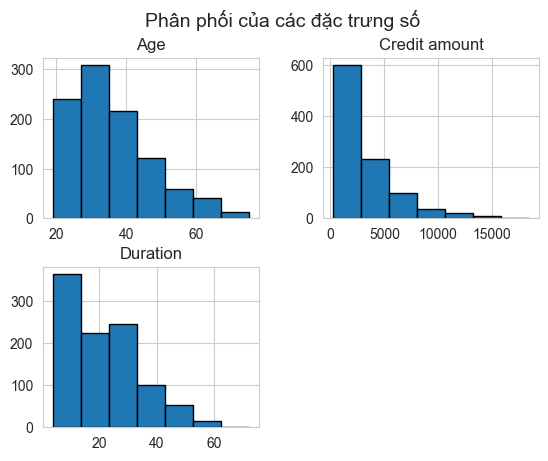

In [20]:
#Histogram
df[["Age","Credit amount","Duration"]].hist(bins=7, edgecolor="black")
plt.suptitle("Phân phối của các đặc trưng số", fontsize= 14)
plt.show()

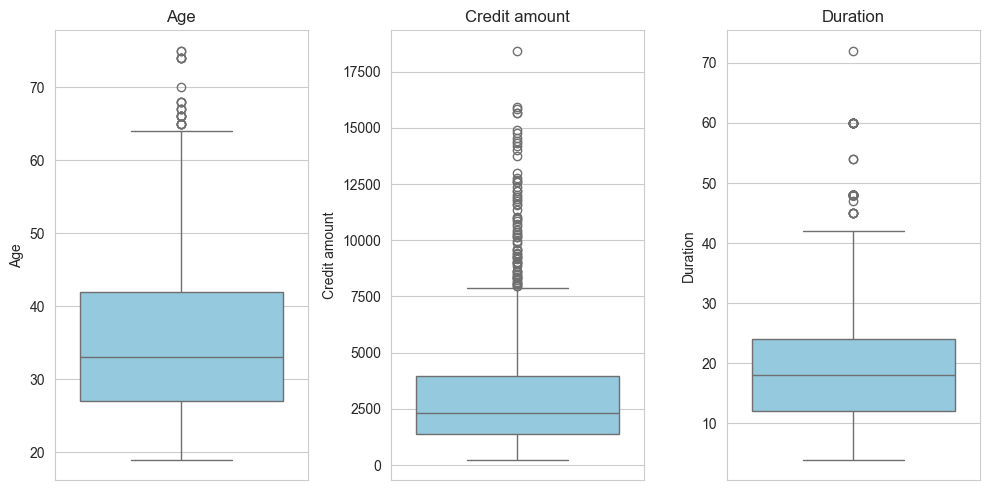

In [21]:
#Boxplot - phát hiện Outliers
plt.figure(figsize=(10,5))
for i , col in enumerate (["Age","Credit amount","Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y = df[col], color= "skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [22]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,Unknown,10144,60,radio/TV,good
255,27,male,1,own,Unknown,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,Unknown,Unknown,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,Unknown,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,Unknown,15653,60,radio/TV,good
672,42,male,3,own,little,Unknown,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [23]:
#Xác định các biến định tính để thực hiện Mã hóa (Encoding).
categorical_cols = ["Sex","Job","Housing","Saving accounts", "Checking account","Purpose"]

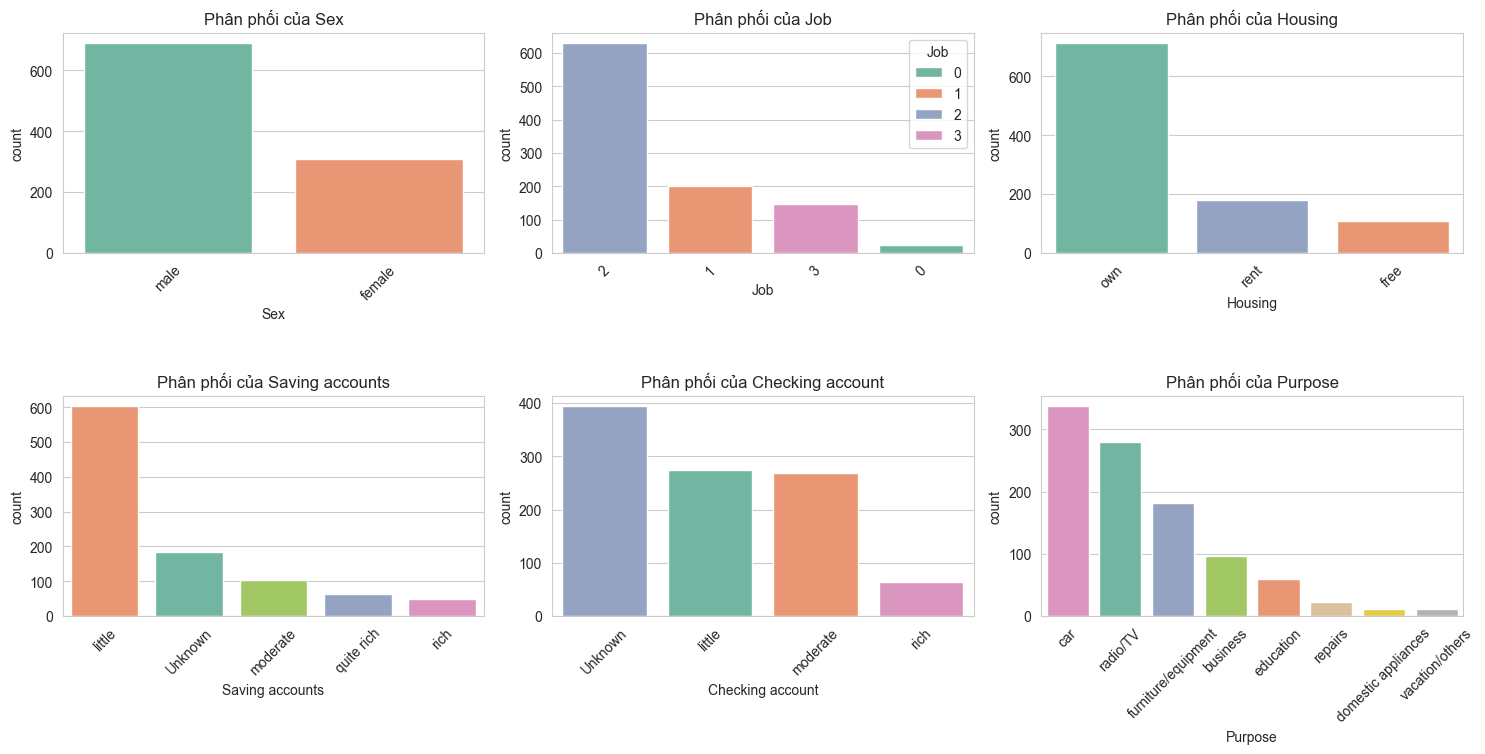

In [24]:
plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data= df, x = col, palette="Set2",hue=col,order=df[col].value_counts().index)
    plt.title(f"Phân phối của {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Ma trận tương quan

In [25]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()

In [26]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


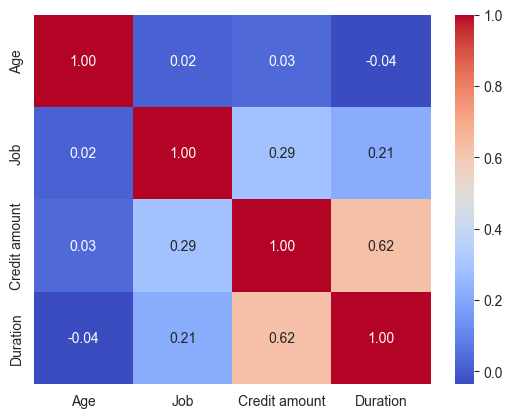

In [27]:
sns.heatmap(corr, annot = True, cmap="coolwarm", fmt=".2f" )
plt.show()

Tương quan mạnh nhất: Credit amount & Duration (Hệ số: 0.62) 
Tương quan trung bình: Job & Credit amount (Hệ số: 0.29)
Tương quan yếu/Không tương quan: Age (Tuổi)

Số tiền vay trung bình theo nhóm công việc

In [28]:
df.groupby("Job")["Credit amount"].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

C:\Users\khanh\AppData\Local\Temp\ipykernel_19180\3876116001.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Job", y="Credit amount", data=job_credit_mean, palette="viridis")


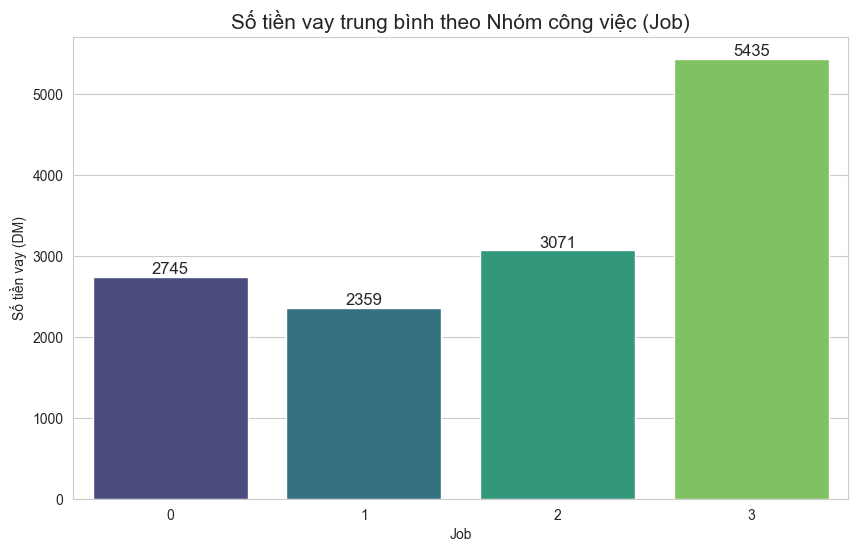

In [29]:
job_credit_mean = df.groupby("Job")["Credit amount"].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Job", y="Credit amount", data=job_credit_mean, palette="viridis")

plt.title("Số tiền vay trung bình theo Nhóm công việc (Job)", fontsize=15)
plt.ylabel("Số tiền vay (DM)")

# Thêm số liệu lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

Số tiền vay trung bình theo nhóm giới tính

In [30]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

C:\Users\khanh\AppData\Local\Temp\ipykernel_19180\3729307218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sex_credit_mean.index, y=sex_credit_mean.values, palette="Set1")


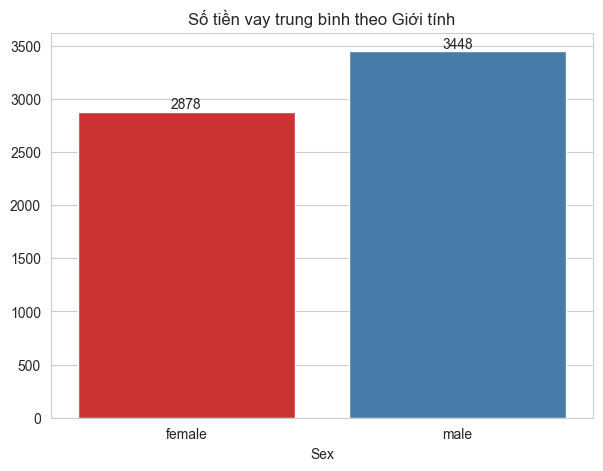

In [31]:
sex_credit_mean = df.groupby("Sex")["Credit amount"].mean()
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=sex_credit_mean.index, y=sex_credit_mean.values, palette="Set1")
plt.title("Số tiền vay trung bình theo Giới tính")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

Số tiền vay trung bình dựa trên sự kết hợp giữa Loại nhà ở và Mục đích vay :

In [32]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


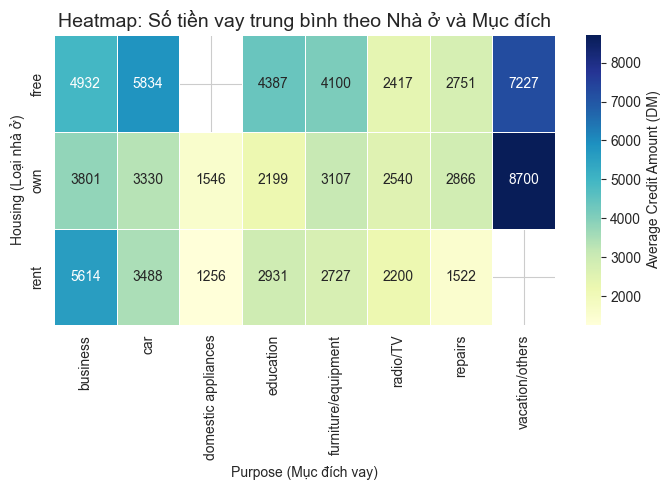

In [33]:
pivot_table_result = pd.pivot_table(df,values="Credit amount", index="Housing", columns="Purpose", aggfunc='mean')
plt.figure(figsize=(7, 5))
sns.heatmap(pivot_table_result, annot=True,fmt=".0f",cmap="YlGnBu",linewidths=.5,cbar_kws={'label': 'Average Credit Amount (DM)'})
plt.title("Heatmap: Số tiền vay trung bình theo Nhà ở và Mục đích", fontsize=14)
plt.ylabel("Housing (Loại nhà ở)")
plt.xlabel("Purpose (Mục đích vay)")
plt.tight_layout()
plt.show()

Biểu đồ thể hiện mối quan hệ giữa 4 đặc trưng:

Trục X: Age (Tuổi)
Trục Y: Credit amount (Số tiền vay)
Màu sắc: Sex (Giới tính)
Kích thước chấm: Duration (Kỳ hạn vay)

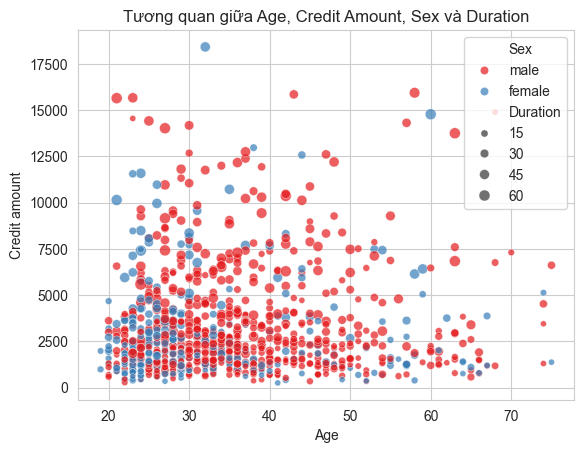

In [34]:
sns.scatterplot(data = df, x="Age", y="Credit amount", hue="Sex", size ="Duration",alpha= 0.7, palette="Set1")
plt.title("Tương quan giữa Age, Credit Amount, Sex và Duration")
plt.show()

Biểu đồ violin

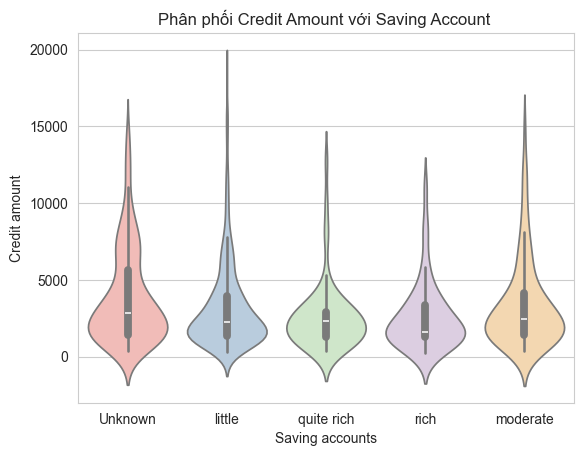

In [35]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount",hue="Saving accounts", palette= "Pastel1")
plt.title("Phân phối Credit Amount với Saving Account ")
plt.show()

Phân phối của biến mục tiêu

In [36]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

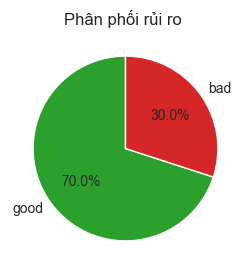

In [37]:
risk_counts = df["Risk"].value_counts()
plt.figure(figsize=(5, 3))
plt.title("Phân phối rủi ro ")
plt.pie(
    risk_counts, 
    labels=risk_counts.index, 
    autopct='%1.1f%%',       # Hiển thị phần trăm với 1 số lẻ
    colors=['#2ca02c', '#d62728'], # Màu xanh lá (Good) và Màu đỏ (Bad)
    startangle=90,           # Xoay biểu đồ để bắt đầu từ góc 90 độ
)
plt.show()

So sánh phân phối các đặc trưng số giữa 2 nhóm khách hàng

<function matplotlib.pyplot.show(close=None, block=None)>

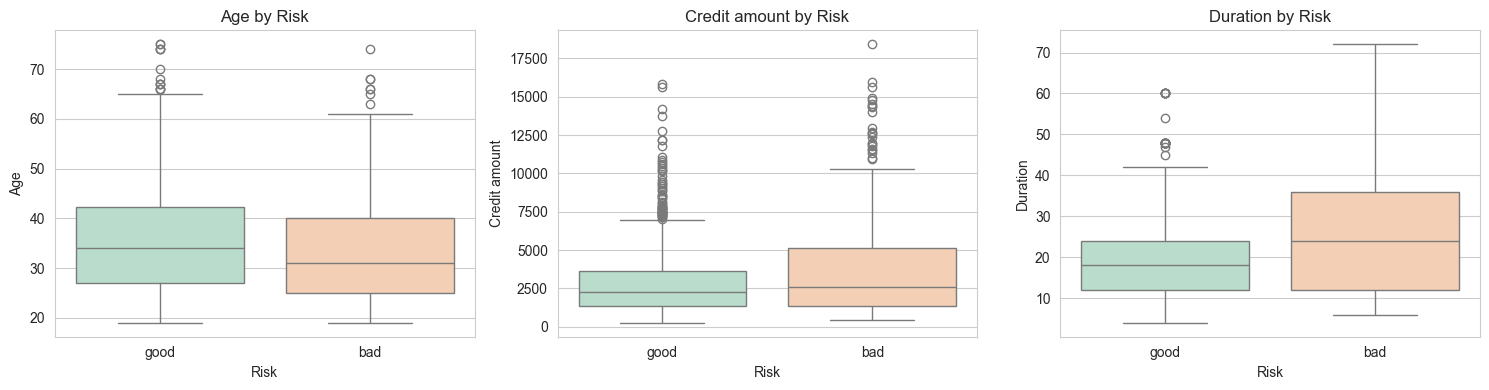

In [38]:
plt.figure(figsize=(15,4))
for i, col in enumerate(["Age","Credit amount", "Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data = df, x="Risk", y= col,hue="Risk", palette="Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show

In [39]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


In [40]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

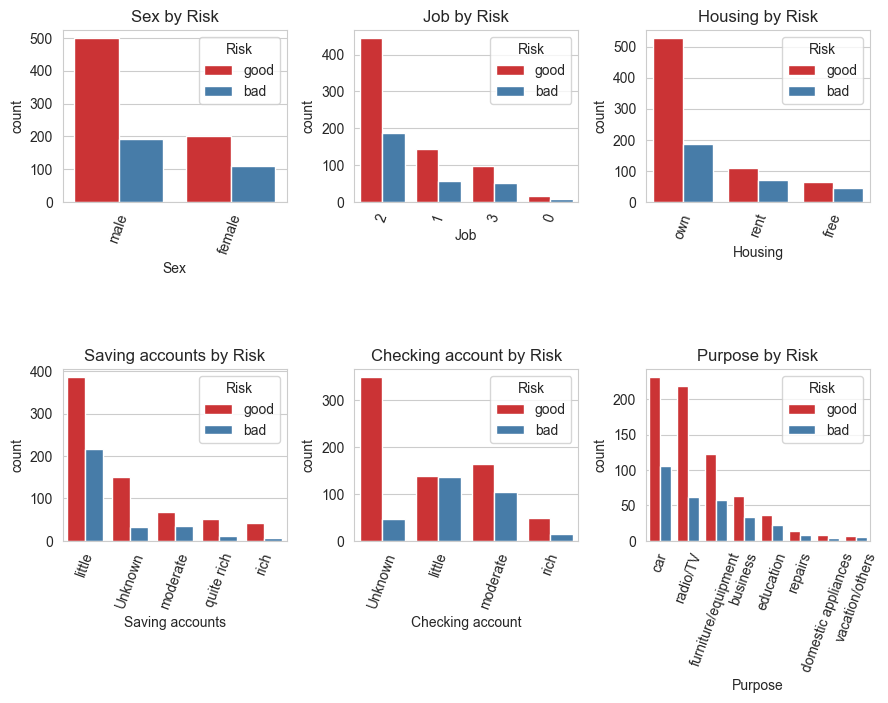

In [41]:
plt.figure(figsize = (9, 9))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data = df, x= col, hue="Risk", palette="Set1", order= df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


Huấn luyện mô hình

Chọn đầu vào, đầu ra của mô hình

In [42]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

Chọn các feature cần thiết để huấn luyện

In [43]:
features = ["Age", "Sex","Job", "Housing","Saving accounts","Checking account","Credit amount","Duration"]

In [44]:
target= "Risk"

In [45]:
df_model= df[features + [target]].copy()

In [46]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,male,2,own,Unknown,little,1169,6,good
1,22,female,2,own,little,moderate,5951,48,bad
2,49,male,1,own,little,Unknown,2096,12,good
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad


Encoder

In [47]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [48]:
cat_cols= df_model.select_dtypes(include="object").columns.drop("Risk")

In [49]:
le_dict = {}

In [50]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [51]:
for col in cat_cols:
    le= LabelEncoder()
    df_model[col]= le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")
    

In [52]:
df_model['Risk'] = df_model['Risk'].astype(str).str.lower().str.strip()
print("Các giá trị duy nhất trong cột Risk:", df_model['Risk'].unique())

Các giá trị duy nhất trong cột Risk: ['good' 'bad']


In [53]:
le_target = df_model['Risk'] = df_model['Risk'].map({'good': 0, 'bad': 1})


In [54]:
df_model[target]

0      0
1      1
2      0
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: Risk, Length: 1000, dtype: int64

In [55]:
df_model[target].value_counts()

Risk
0    700
1    300
Name: count, dtype: int64

In [56]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [57]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,1,2,1,0,1,1169,6,0
1,22,0,2,1,1,2,5951,48,1
2,49,1,1,1,1,0,2096,12,0
3,45,1,2,0,1,1,7882,42,0
4,53,1,2,0,1,1,4870,24,1


In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X = df_model.drop(target, axis = 1)

In [60]:
y= df_model[target]

In [61]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,67,1,2,1,0,1,1169,6
1,22,0,2,1,1,2,5951,48
2,49,1,1,1,1,0,2096,12
3,45,1,2,0,1,1,7882,42
4,53,1,2,0,1,1,4870,24
...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12
996,40,1,3,1,1,1,3857,30
997,38,1,2,1,1,0,804,12
998,23,1,2,0,1,1,1845,45


In [62]:
y

0      0
1      1
2      0
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: Risk, Length: 1000, dtype: int64

Chia tập dữ liệu để test

In [63]:
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=1)

In [64]:
X_train.shape

(800, 8)

In [65]:
X_test.shape

(200, 8)

Khai báo thư viện model

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    roc_curve,
   
)
from sklearn.model_selection import GridSearchCV

Gọi hàm train

In [67]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model , param_grid, cv=5, scoring="roc_auc", n_jobs = -1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }
    return best_model, metrics, grid.best_params_

DECISION TREE

In [68]:
dt = DecisionTreeClassifier(random_state=1, class_weight= "balanced")
dt_param_grid = {
    "max_depth" : [3,5,7,10, None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [69]:
best_dt, metrics_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test
)

In [70]:
y_pred_dt = best_dt.predict(X_test)

In [71]:
print(f"Accuracy : {metrics_dt['accuracy']:}")
print(f"Precision: {metrics_dt['precision']:}")
print(f"Recall   : {metrics_dt['recall']:}")
print(f"F1-score : {metrics_dt['f1']:}")
print(f"ROC-AUC  : {metrics_dt['roc_auc']:}")
print("===== Decision Tree Classification Report =====")
print(classification_report(y_test, y_pred_dt))


Accuracy : 0.69
Precision: 0.49056603773584906
Recall   : 0.8666666666666667
F1-score : 0.6265060240963856
ROC-AUC  : 0.7686309523809525
===== Decision Tree Classification Report =====
              precision    recall  f1-score   support

           0       0.91      0.61      0.74       140
           1       0.49      0.87      0.63        60

    accuracy                           0.69       200
   macro avg       0.70      0.74      0.68       200
weighted avg       0.79      0.69      0.70       200



In [72]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}


RANDOM FOREST

In [73]:
rf= RandomForestClassifier(random_state=1, class_weight="balanced")

In [74]:
rf_param_grid ={
    "n_estimators": [100,200],
    "max_depth": [5 ,7, 10, None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [75]:
best_rf, metrics_rf, params_rf = train_model(rf, rf_param_grid,X_train, y_train, X_test, y_test)

In [76]:
y_pred_rf = best_rf.predict(X_test)

In [77]:
print(f"Accuracy : {metrics_rf['accuracy']:}")
print(f"Precision: {metrics_rf['precision']:}")
print(f"Recall   : {metrics_rf['recall']:}")
print(f"F1-score : {metrics_rf['f1']:}")
print(f"ROC-AUC  : {metrics_rf['roc_auc']:}")
print("===== Random Forest Classification Report =====")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.765
Precision: 0.5730337078651685
Recall   : 0.85
F1-score : 0.6845637583892618
ROC-AUC  : 0.8466666666666667
===== Random Forest Classification Report =====
              precision    recall  f1-score   support

           0       0.92      0.73      0.81       140
           1       0.57      0.85      0.68        60

    accuracy                           0.77       200
   macro avg       0.75      0.79      0.75       200
weighted avg       0.82      0.77      0.77       200



In [78]:
print("Best parameters",params_rf)

Best parameters {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


XGBOOST

In [79]:
xgb = XGBClassifier(random_state = 1, scale_pos_weight = (y_train == 0).sum() / (y_train==1).sum(),   eval_metric="logloss"  )

In [80]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5,7],
    "learning_rate": [0.01,0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree":[0.7, 1]
}

In [81]:
best_xgb, metrics_xgb , params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

In [82]:
y_pred_xgb = best_xgb.predict(X_test)

In [83]:
print(f"Accuracy : {metrics_xgb['accuracy']:}")
print(f"Precision: {metrics_xgb['precision']:}")
print(f"Recall   : {metrics_xgb['recall']:}")
print(f"F1-score : {metrics_xgb['f1']:}")
print(f"ROC-AUC  : {metrics_xgb['roc_auc']:}")
print("===== XGBoost Classification Report =====")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.77
Precision: 0.5897435897435898
Recall   : 0.7666666666666667
F1-score : 0.6666666666666666
ROC-AUC  : 0.8333333333333333
===== XGBoost Classification Report =====
              precision    recall  f1-score   support

           0       0.89      0.77      0.82       140
           1       0.59      0.77      0.67        60

    accuracy                           0.77       200
   macro avg       0.74      0.77      0.75       200
weighted avg       0.80      0.77      0.78       200



In [84]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}


In [85]:

joblib.dump(best_xgb, "xgboost.pkl")

['xgboost.pkl']

In [86]:
joblib.dump(best_dt, "decision_tree.pkl")


['decision_tree.pkl']

In [87]:
joblib.dump(best_rf, "random_forest.pkl")

['random_forest.pkl']

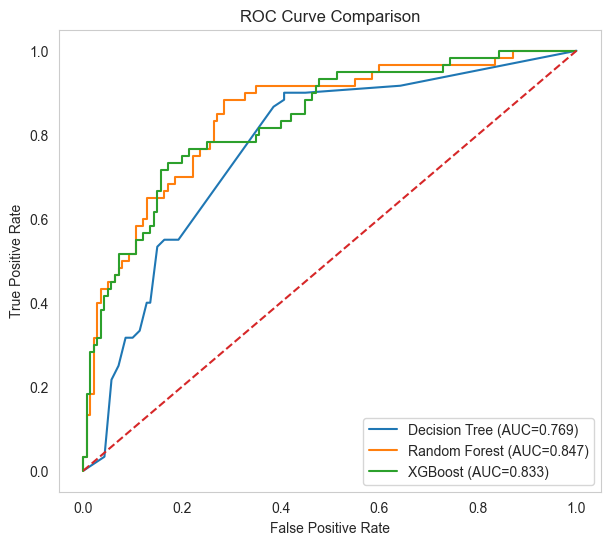

In [88]:
models = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

plt.figure(figsize=(7,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()
